# Churn Analysis and Customer Intelligence

In [6]:
#importing libraries
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [16]:
#1. import database
conn = sqlite3.connect('customer_churn.db copy')
sql_query = """
       SELECT name 
       FROM sqlite_master
       WHERE type = 'table'
"""
tables = pd.read_sql(sql_query , conn)

# create dataframe for each table 
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}" , conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")

conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [17]:
conn = sqlite3.connect('customer_churn.db copy')

for table_name in tables['name']:
    print(f"\nTable Name:{table_name}")
    coloumns_query = f"PRAGMA table_info({table_name});"
    coloumns = pd.read_sql(coloumns_query , conn)
    print("columns:")
    print(coloumns['name'].tolist())

conn.close()


Table Name:db_customer
columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name:db_subscription
columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name:db_support
columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [24]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [29]:
# Data cleaning
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerid     21 non-null     str   
 1   customer_name  21 non-null     str   
 2   country        18 non-null     str   
 3   state          21 non-null     str   
 4   gender         21 non-null     str   
 5   dob            21 non-null     str   
 6   interests      4 non-null      str   
 7   pincode        0 non-null      object
dtypes: object(1), str(7)
memory usage: 2.5+ KB


In [30]:
# rename col - name
df_db_customer.rename(columns={'name': 'customer_name'}, inplace=True)
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10 00:00:00,NaN,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,NaN,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,NaN,None
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07 00:00:00,NaN,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,NaN,None


In [36]:
# drop coloums - interest and pincode 
df_db_customer.drop(columns=['interests', 'pincode'], inplace=True, errors='ignore')
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [ ]:
# change to datetime datatype
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [ ]:
# data standardization 
df_db_customer['gender'].unique()
df_db_customer['gender'].replace({'Men':'Male' , 'Women':'Female'})

0       Male
1       Male
2     Female
3       Male
4     Female
5     Female
6     Female
7       Male
8     Female
9       Male
10      Male
11    Female
12    Female
13    Female
14      Male
15    Female
16    Female
17    Female
18      Male
19      Male
20    Female
Name: gender, dtype: str

In [ ]:
#fix missing values of country
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [45]:
state_country = df_db_customer.dropna(subset = ['country']).set_index('state')['country'].to_dict()
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country))

In [46]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [47]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [48]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 3.1 KB


In [54]:
date_col = ['subscription_start_date','renewal_date','cancellation_date']
df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 2.7 KB


In [55]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [56]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 895.0+ bytes


In [57]:
df_db_support.drop(columns=['col_1', 'comment'], inplace=True, errors='ignore')

In [58]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 519.0 bytes


## Feature engineering

In [60]:
#creating a new coloum usin existing coloum
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [64]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [67]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep ='last')

In [126]:
# merge dataframe
df = (df_db_subscription
            .merge(df_db_customer, on = 'customerid' , how = 'left')
            .merge(df_db_support, on = 'customerid' , how = 'left'))
df

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,NaN,17.99,720,...,0,durga,India,Delhi,Women,1988-12-10,2025-03-18,N,90.0,1.0
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,...,1,mina,India,Meghalaya,Female,1976-09-21,2024-11-01,N,30.0,1.0
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,NaN,22.99,1840,...,0,madan,India,Rajasthan,Male,1999-03-14,NaT,NaN,NaN,NaN
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,NaN,13.99,240,...,0,maya,Nepal,Kathmandu,Women,1985-07-07,NaT,NaN,NaN,NaN
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,NaN,6.99,335,...,0,arjun,Nepal,Kathmandu,Male,1993-10-29,NaT,NaN,NaN,NaN


In [70]:
df.to_csv('exported_churn_data.csv', index = False)

## Data Analysis

In [74]:
# Churn rate 
churn_rate = df['churn_flag'].mean()*100
print("churn rate = ",round(churn_rate,2),"%")

churn rate =  28.57 %


In [76]:
#Retention rate
retention_rate = 100 - churn_rate
print("retention rate = ", round(retention_rate,2),"%")

retention rate =  71.43 %


In [80]:
# churn by plan type
churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))
print( churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [81]:
# churn by state
churn_by_state = (df.groupby('state')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_state'))
print( churn_by_state)

           state  churn_rate_state
0          Delhi             25.00
1      Karnataka            100.00
2      Kathmandu              0.00
3    Maharashtra              0.00
4      Meghalaya             66.67
5       Nagaland              0.00
6      Rajasthan              0.00
7      Telangana             50.00
8  Uttar Pradesh              0.00


In [85]:
# churn by subscription type
churn_by_subscription = (df.groupby('subscription_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_state'))
print( churn_by_subscription)

  subscription_type  churn_rate_state
0           Organic              0.00
1              Paid             16.67
2          Refferal             83.33


In [84]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [87]:
# ARPU [Average Revenue Per User] IMP
arpu = df['monthly_charges'].mean()
print('ARPU =' , round(arpu,2))

ARPU = 18.85


In [95]:
# Average Customer Tenure
# count of days users had used our service 
today = pd.Timestamp.today()
df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),
(df['cancellation_date'] - df['subscription_start_date']).dt.days,
(today - df['subscription_start_date']).dt.days
)
avg_tenure = df['tenure_days'].mean()
print("Average Tenure days = ", round(avg_tenure))

Average Tenure days =  1542


In [99]:
# Revenue loss from churned users
revenue_at_risk = df.loc[df['churn_flag'] == 1,'monthly_charges'].sum()
print("Revenue at risk (Rs 'k')=",revenue_at_risk )

Revenue at risk (Rs 'k')= 73.94


In [104]:
# Escalation Rate
escalation_rate = (df['escalations'] == 'Y').mean()*100
print("Escalation Rate = " ,round(escalation_rate,2),"%")

Escalation Rate =  19.05 %


In [106]:
# Average Complaint Per User
avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print("avg complaints per user = ", round(avg_complaints , 2))

avg complaints per user =  0.43


In [ ]:
# churn risk - creating a new data
conditions = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 70)
]
choices = ['low','med','high']
df['churn_risk'] = np.select(conditions,choices,default = 'unknown')
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,NaN,10.0,2.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,mira,India,Delhi,Female,1990-05-05,2024-01-20,NaN,20.0,1.0,high


# Data Visualisation

In [137]:
df_visual = df.copy()
# Monthly Churn Trend
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'churn_risk'],
      dtype='str')

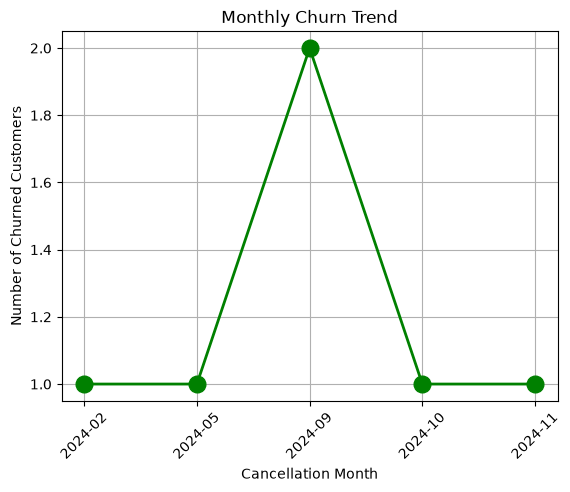

In [145]:
# Monthly Churn Trend
df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = (
    df_visual[df_visual['churn_flag'] == 1]
    .groupby('cancellation_month')
    .size()
)

plt.plot(
    churn_trend.index.astype(str),
    churn_trend.values,
    color='green',
    marker='o',          
    linewidth=2,
    markersize=12
)
plt.xlabel('Cancellation Month')
plt.ylabel('Number of Churned Customers')
plt.title('Monthly Churn Trend')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

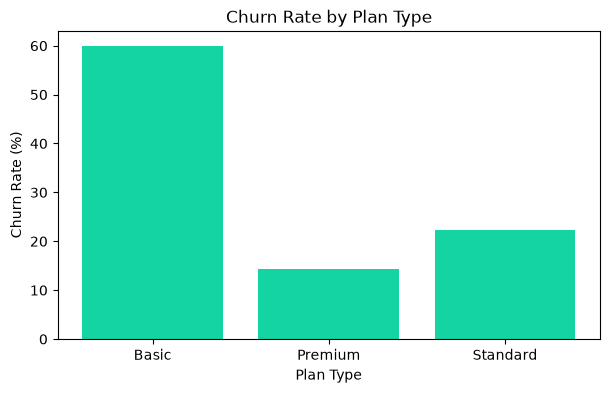

In [151]:
# Churn by Plan type 
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean() * 100
colors = ['#15D4A4', '#15D4A4' , '#15D4A4']
plt.figure(figsize=(7, 4))

plt.bar(churn_plan.index, churn_plan.values ,color = colors)

plt.xlabel('Plan Type')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Plan Type')

plt.show()

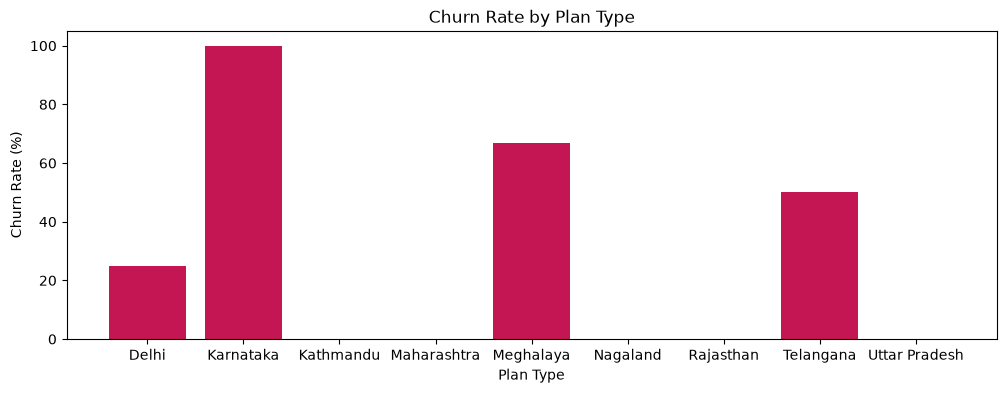

In [154]:
# Churn by states
churn_plan = df_visual.groupby('state')['churn_flag'].mean() * 100
colors = ['#C41652', '#C41652' , '#C41652']
plt.figure(figsize=(12, 4))

plt.bar(churn_plan.index, churn_plan.values ,color = colors)

plt.xlabel('Plan Type')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Plan Type')

plt.show()


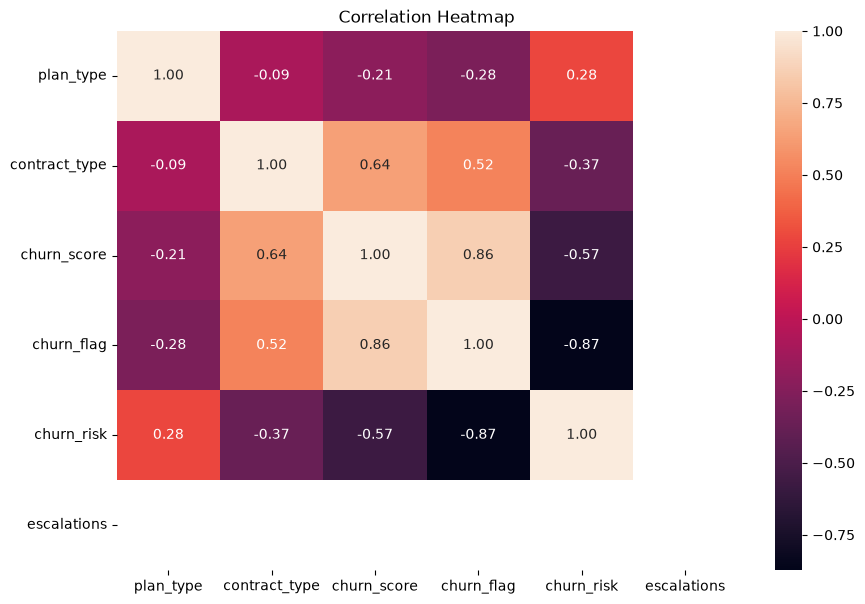

In [161]:
# Corrlation heatmap
import warnings
warnings.filterwarnings("ignore")

df_encoded = df_visual[
    ['plan_type', 'contract_type', 'churn_score',
     'churn_flag', 'churn_risk', 'escalations']
].copy()

categorical_cols = ['plan_type', 'contract_type', 'churn_risk']

for col in categorical_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

# Create correlation matrix
corr_matrix = df_encoded.corr()

# Plot heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

In [166]:
# Pivot tables
pd.pivot_table(
        df_visual,
        values ='churn_flag',
        index = 'plan_type',
        aggfunc = 'mean'
).reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [167]:
pd.pivot_table(
        df_visual,
        index = 'plan_type', 
        values =['monthly_charges','customerid','churn_flag'],
        aggfunc = {
              'monthly_charges': 'sum',
              'customerid' : 'nunique',
              'churn_flag': 'mean'
        }
).reset_index()

,plan_type,churn_flag,customerid,monthly_charges
0,Basic,0.600000,5,52.95
1,Premium,0.142857,7,218.93
2,Standard,0.222222,9,123.91


In [193]:
# Working with SQL in python (pandas)
import sqlite3

conn = sqlite3.connect('test_database.sqlite')

cursor = conn.cursor()

cursor.execute("""
    INSERT INTO users (first_name, country, budget)
    VALUES
        ('Madhav', 'India', 5000),
        ('Rohan', 'Germany', 8000),
        ('Yazdan', 'London', 9000)
""")
print("Data Inserted Successfully")
conn.commit()

Data Inserted Successfully


In [195]:
conn = sqlite3.connect('test_database.sqlite')
query = """ SELECT * FROM users """
df_results = pd.read_sql(query,conn)

In [187]:
# Aggregation function
query = """
        SELECT country , sum(budget) as total_budget
        FROM users
        GROUP BY country
    """
df_agg = pd.read_sql(query,conn)
print(df_agg)
conn.close()

   country  total_budget
0  Germany         24000
1    India         15000
2   London         27000
